# Superstore Sales EDA

## Project Summary
Exploratory Data Analysis on the Superstore Sales dataset (9,994 rows, 21 columns).
This notebook covers data cleaning, visual EDA, and answers 5 business questions
using Python, pandas, matplotlib, and seaborn.

## Dataset
- Source: Kaggle — Sample Superstore Dataset
- Period: 2014 to 2017
- Columns: Order details, customer segments, categories, sales, profit, discount

## 5 Business Insights
1. **Technology** is the most profitable category. Furniture has a 2% margin despite high sales.
2. **West region** leads in both sales and profit. Central region has a margin efficiency problem.
3. **Standard Class** shipping is used in 60% of orders — customers prioritize cost over speed.
4. **Discounts above 30%** consistently result in negative profit across all categories.
5. **Tables and Bookcases** are loss-making sub-categories — they need pricing review.

## Tools Used
Python, pandas, numpy, matplotlib, seaborn

In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
print(df.shape)
print(df.columns.tolist())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [2]:
print("Loaded successfully:", df.shape)

Loaded successfully: (9994, 21)


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [5]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
#Null Values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
#Duplicates
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [10]:
#column name has spaces
df.columns=df.columns.str.strip().str.replace(' ','_').str.lower()
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [11]:
#data columns are likely a plain objects 
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date']=pd.to_datetime(df['ship_date'])
print(df[['order_date','ship_date']].dtypes)

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


In [12]:
#Extract useful columns from dates
df['order_year']=df['order_date'].dt.year
df['order_month']=df['order_date'].dt.month
df['order_month_name']=df['order_date'].dt.month_name()
df['shipping_days']=(df['ship_date']-df['order_date']).dt.days

In [13]:
# Negative profits
print("Negative profits rows:",(df['profit']<0).sum())

# Any zero or negative sales?
print("Zero / Negative sales:",(df['sales']<=0).sum())

#Discount range
print(df['discount'].describe())

Negative profits rows: 1871
Zero / Negative sales: 0
count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: discount, dtype: float64


- ## Initial Observations
- The dataset has 9994 rows and 21 columns
- 'Order Date' and 'Ship Date' is loaded as object, needs to be converted to datetime
- the discount range is 20% to 80%
- No duplicate rows found

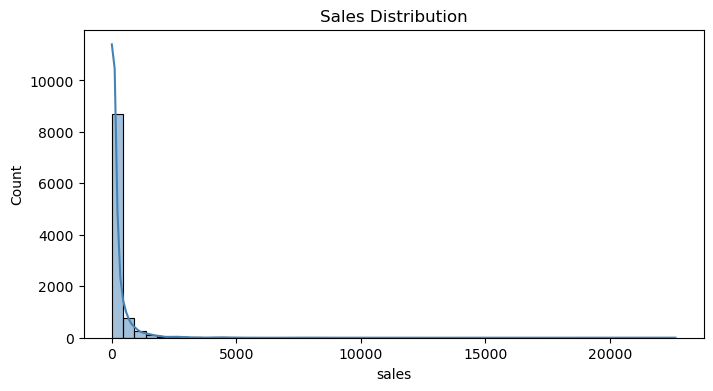

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
#Sales distribution
plt.figure(figsize=(8,4))
sns.histplot(df['sales'],bins=50,kde=True,color='steelblue')
plt.title('Sales Distribution')
plt.savefig('../visuals/sales_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

Sales is heavily right-skewed. Most orders are under ₹1000 in value, but a few outliers go up to ₹22,000+. This means the business runs on high-volume small orders, not big-ticket deals.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\2895042265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales,x='category',y='sales',palette='Set2')


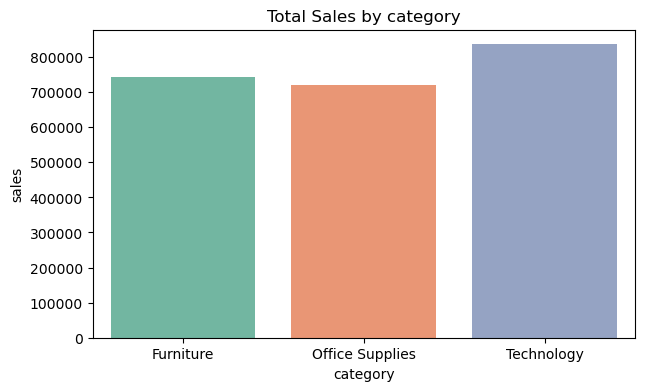

In [15]:
plt.figure(figsize=(7,4))
category_sales=df.groupby('category')['sales'].sum().reset_index()
sns.barplot(data=category_sales,x='category',y='sales',palette='Set2')
plt.title("Total Sales by category")
plt.savefig('../visuals/sales_by_category.png',dpi=150,bbox_inches='tight')
plt.show()

All three categories have similar total sales (~700K–840K). Technology leads slightly, but the gap is not dramatic. Sales alone is not a good performance metric here.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\2713582777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit,x='category',y='profit',palette='Set1')


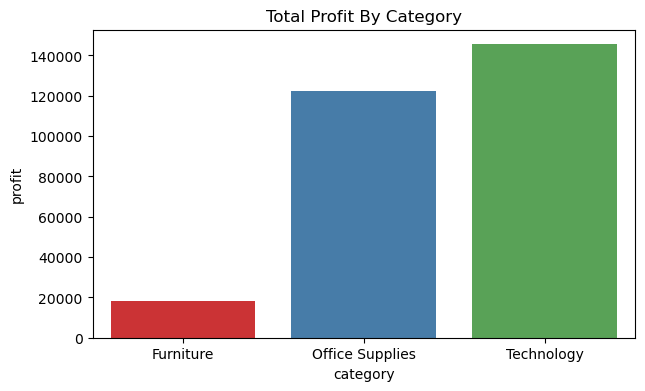

In [16]:
#Profit by Category
plt.figure(figsize=(7,4))
category_profit=df.groupby('category')['profit'].sum().reset_index()
sns.barplot(data=category_profit,x='category',y='profit',palette='Set1')
plt.title('Total Profit By Category')
plt.savefig('../visuals/profit_by_category.png',dpi=150,bbox_inches='tight')
plt.show()

This is the biggest insight. Furniture has ~18K profit despite ~740K in sales. That's barely a 2% margin. Technology and Office Supplies show 15–17% margins.

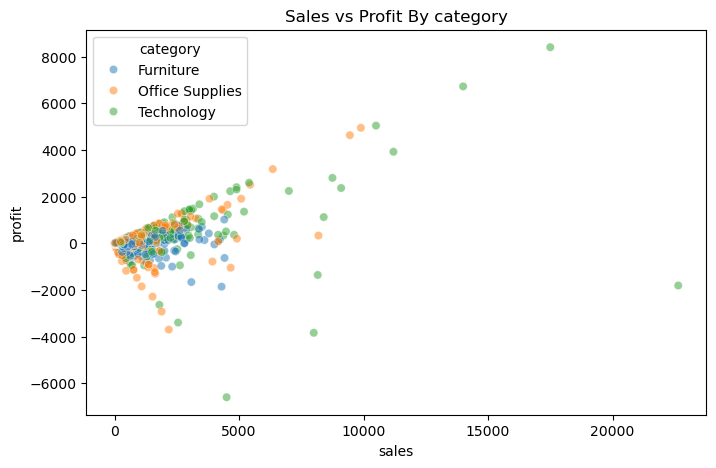

In [17]:
#Sales vs Profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='sales',y='profit',hue='category',alpha=0.5)
plt.title('Sales vs Profit By category')
plt.savefig('../visuals/sales_vs_profit_by_category.png',dpi=150,bbox_inches='tight')
plt.show()


You can clearly see Furniture (blue) dots clustering near zero or below profit line despite decent sales values. Some orders show -6000 profit — those are loss-making orders, likely due to heavy discounts.

## 1.Which category is most profitable?
#### Technology, followed by Office Supplies. Furniture generates revenue but barely any profit — a classic discount abuse pattern.

In [18]:
#Region sales and profit
region_summary=df.groupby('region')[['sales','profit']].sum().reset_index()
region_summary

,region,sales,profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\3277419973.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary,x='region',y='sales',palette='Blues')


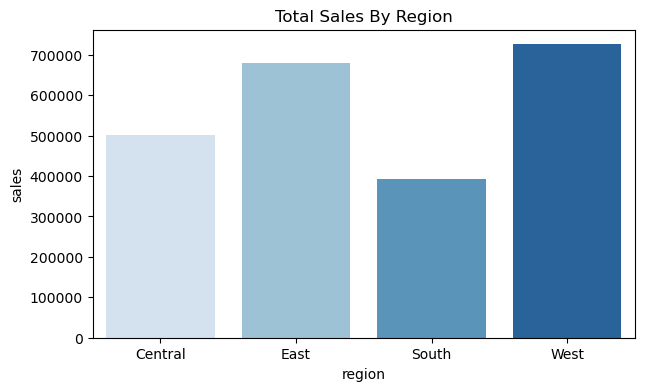

In [19]:
#Plot region sales
plt.figure(figsize=(7,4))
sns.barplot(data=region_summary,x='region',y='sales',palette='Blues')
plt.title('Total Sales By Region')
plt.savefig('../visuals/total_sales_by_region.png',dpi=150,bbox_inches='tight')
plt.show()

West leads with ~725K, followed by East at ~680K. Central and South lag behind. This is Business Question 2 answered: West and East are the top-performing regions. South needs investigation — is it low orders or low order value?

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\1634584602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_summary,x='region',y='profit',palette='Greens')


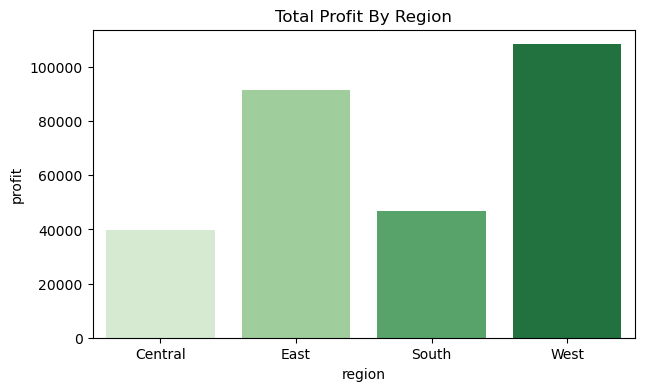

In [20]:
#Plot region profit
plt.figure(figsize=(7,4))
sns.barplot(data=region_summary,x='region',y='profit',palette='Greens')
plt.title('Total Profit By Region')
plt.savefig('../visuals/total_profit_by_region.png',dpi=150,bbox_inches='tight')
plt.show()

Central is generating more revenue but losing efficiency somewhere — likely heavy discounting or high-cost products being sold at thin margins.

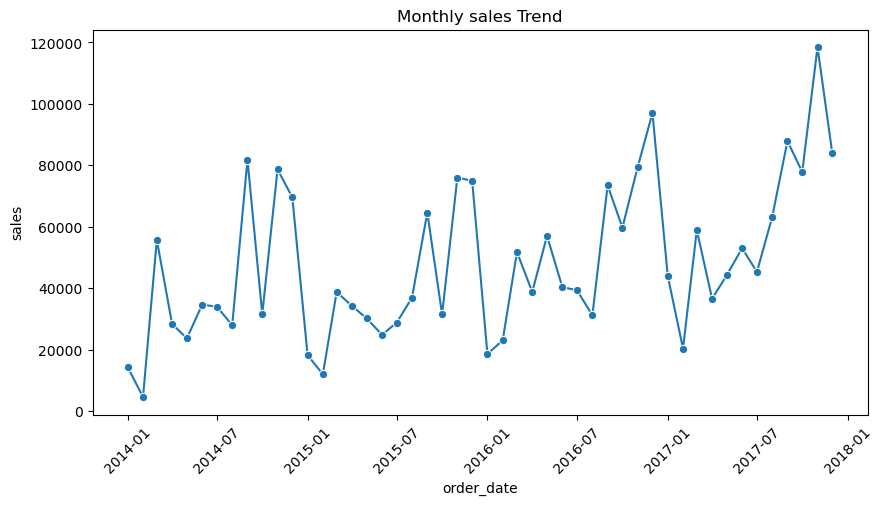

In [21]:
#Monthly sales trend
monthly_sales=df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum().reset_index()
monthly_sales['order_date']=monthly_sales['order_date'].dt.to_timestamp()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales,x='order_date',y='sales',marker='o')
plt.title('Monthly sales Trend')
plt.xticks(rotation=45)
plt.savefig('../visuals/montly_sales_trend.png',dpi=150,bbox_inches='tight')
plt.show()

Sales show a clear upward trend from 2014 to 2017, with recurring dips in January/February each year — classic post-holiday slowdown. The highest spike is November 2017 (~118K), suggesting strong year-end sales. This is a seasonality pattern worth highlighting.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\3914591466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ship_mode_counts,x='ship_mode',y='count',palette="Set2")


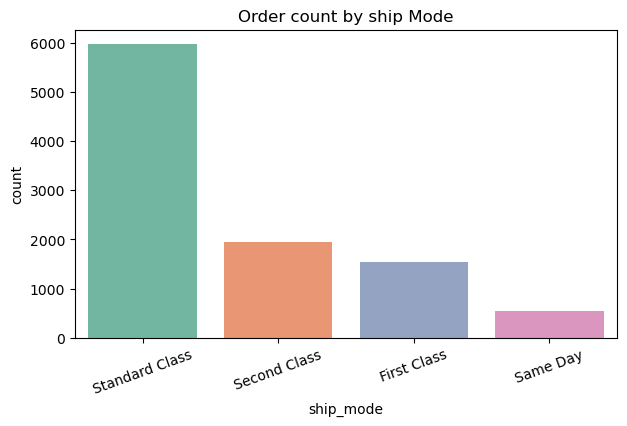

In [22]:
#Ship mode count
ship_mode_counts=df['ship_mode'].value_counts().reset_index()
ship_mode_counts.columns=['ship_mode','count']

plt.figure(figsize=(7,4))
sns.barplot(data=ship_mode_counts,x='ship_mode',y='count',palette="Set2")
plt.title("Order count by ship Mode")
plt.xticks(rotation=20)
plt.savefig('../visuals/order_count_by_ship_mode.png',dpi=150,bbox_inches='tight')
plt.show()

Standard Class dominates with ~6000 orders — that's 60% of all orders. Same Day is barely used (~550). This tells us customers prefer economy over speed, which has logistics cost implications

In [23]:
df['shipping_days']=(df['ship_date']-df['order_date']).dt.days
df[['shipping_days','sales','profit']].describe()

,shipping_days,sales,profit
count,9994.000000,9994.000000,9994.000000
mean,3.958175,229.858001,28.656896
std,1.747567,623.245101,234.260108
min,0.000000,0.444000,-6599.978000
25%,3.000000,17.280000,1.728750
50%,4.000000,54.490000,8.666500
75%,5.000000,209.940000,29.364000
max,7.000000,22638.480000,8399.976000


## 2.Which region has highest sales?
#### West, followed by East

## 3.What ship mode do customers prefer?
#### Standard Class (60% of orders)

In [24]:
#Sub-category sales
subcat_sales=df.groupby('sub-category')['sales'].sum().sort_values(ascending=False).reset_index()
subcat_sales

,sub-category,sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\1968886986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_sales,x='sub-category',y='sales',palette='viridis')


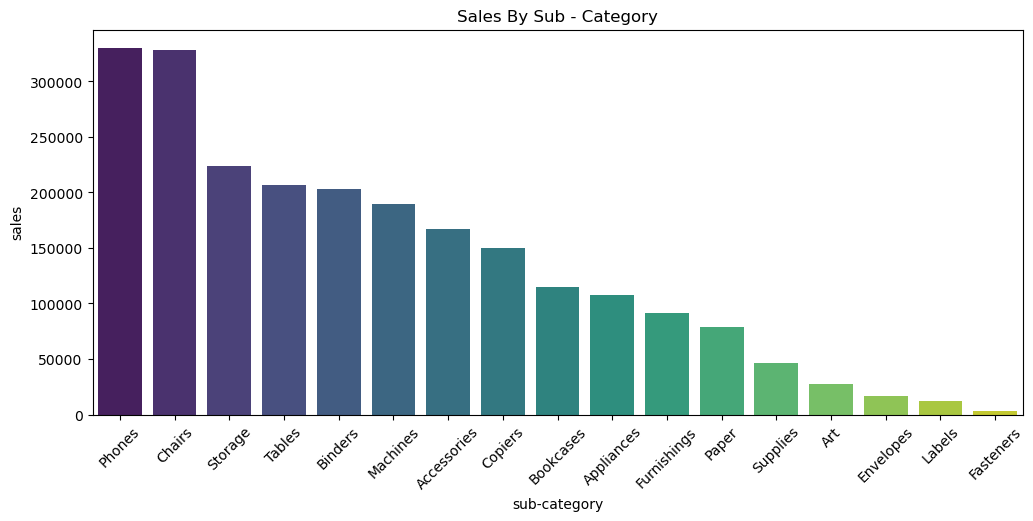

In [25]:
# Plot sub-category sales
plt.figure(figsize=(12,5))
sns.barplot(data=subcat_sales,x='sub-category',y='sales',palette='viridis')
plt.title('Sales By Sub - Category')
plt.xticks(rotation=45)
plt.savefig('../visuals/sales-bysub-category.png',dpi=150,bbox_inches='tight')
plt.show()

Phones and Chairs are the top revenue generators (~330K each), followed by Storage and Tables. Fasteners, Labels, and Envelopes are the weakest. The top 2 sub-categories alone account for nearly 30% of total sales.

In [26]:
# Sub-category profit
subcat_profit=df.groupby('sub-category')['profit'].sum().sort_values(ascending=False).reset_index()
subcat_profit

,sub-category,profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_29072\741467873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit,x='sub-category',y='profit',palette='coolwarm')


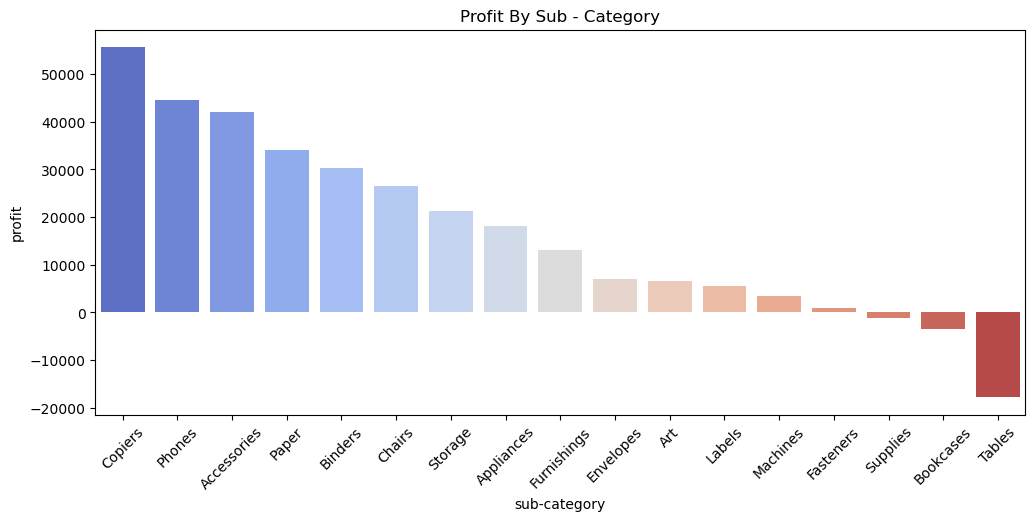

In [27]:
#Plot sub-category profit
plt.figure(figsize=(12,5))
sns.barplot(data=subcat_profit,x='sub-category',y='profit',palette='coolwarm')
plt.title('Profit By Sub - Category')
plt.xticks(rotation=45)
plt.savefig('../visuals/profit-by-sub-category.png',dpi=150,bbox_inches='tight')
plt.show()

Copiers, Phones, and Accessories are the most profitable sub-categories. But look at the right side — Tables (~-18K) and Bookcases (~-3K) have negative total profit. These two are Furniture sub-categories. They are generating decent sales but are actively losing money. This confirms the Furniture margin problem that I spotted on Day 2

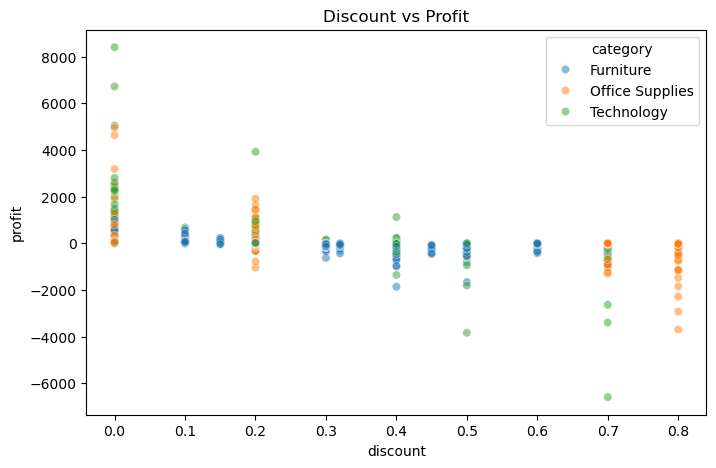

In [28]:
#Discount vs profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='discount',y='profit',hue='category',alpha=0.5)
plt.title('Discount vs Profit')
plt.savefig('../visuals/discount-vs-profit.png',dpi=150,bbox_inches='tight')
plt.show()

The pattern is very clear — at discount = 0, profits are positive and high. As discount increases past 0.3–0.4, profits start going negative across all categories. At discount = 0.7 and 0.8, almost every order is a loss. Heavy discounting is the direct cause of negative profit.

In [29]:
df.groupby('category')[['discount','sales','profit']].mean().reset_index()

,category,discount,sales,profit
0,Furniture,0.173923,349.834887,8.699327
1,Office Supplies,0.157285,119.324101,20.327050
2,Technology,0.132323,452.709276,78.752002


## 4.Does discounting hurt profit?
#### Yes — discounts above 30% consistently cause losses

## 5. Which sub-categories are loss-making?
#### Tables and Bookcases — negative total profit

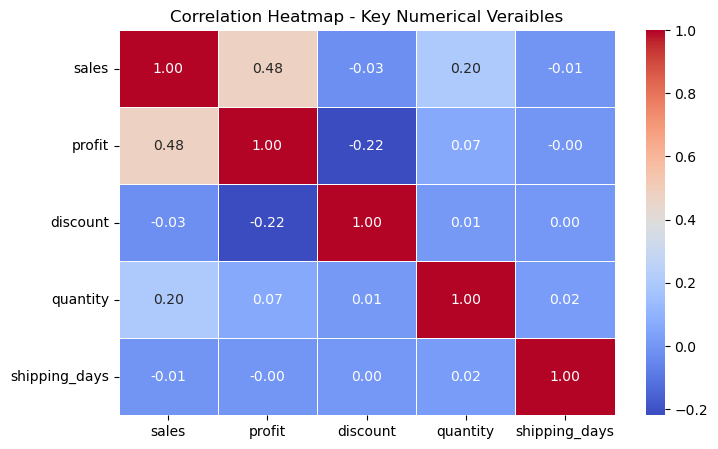

In [30]:
#Correlation Heatmap
plt.figure(figsize=(8,5))
corr=df[['sales','profit','discount','quantity','shipping_days']].corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap - Key Numerical Veraibles")
plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()